In [1]:
import gc
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ScLdaSimData import ScLdaSimData
from LDA import LDA

%matplotlib inline

## Simulation configuration

In [2]:
N_CELLS = 500
N_GENES = 300
N_TOPICS = 5
N_REPS = 3
BASE_SEED = 1

MEAN_LIBRARY_SIZE = 100.0
ETA_TRUE = 0.05
ALPHA_TRUE = 0.2
ETA_FIT = 0.05
ALPHA_FIT = 0.2
TRAIN_FRACTION = 0.8

CAVI_MAX_ITER = 3
SVI_MAX_STEPS = 30
BATCH_SIZE = 100
TAU0 = 1.0
KAPPA = 0.6
EVAL_SIZE = 100
METHODS = ("CAVI", "SVI")
RESULTS_DIR = Path("../../results/scLDA")

In [3]:
def run_one_simulation(rep_id, seed):
    sim = ScLdaSimData.simulate(
        n_cells=N_CELLS,
        n_genes=N_GENES,
        n_topics=N_TOPICS,
        mean_library_size=MEAN_LIBRARY_SIZE,
        eta=ETA_TRUE,
        alpha=ALPHA_TRUE,
        seed=seed,
    )
    train_counts, test_counts = sim.train_test_split(TRAIN_FRACTION, seed + 10_000)

    rng = np.random.default_rng(seed + 20_000)
    eval_indices = np.sort(rng.choice(N_CELLS, size=min(EVAL_SIZE, N_CELLS), replace=False))
    model = LDA(n_topics=N_TOPICS, alpha=ALPHA_FIT, eta=ETA_FIT, seed=seed + 30_000)
    history = model.fit(
        train_counts,
        test_counts,
        sim.beta_true,
        methods=METHODS,
        cavi_max_iter=CAVI_MAX_ITER,
        svi_max_steps=SVI_MAX_STEPS,
        batch_size=BATCH_SIZE,
        tau0=TAU0,
        kappa=KAPPA,
        eval_every_cavi=1,
        eval_every_svi=10,
        eval_indices=eval_indices,
    )
    history.insert(0, "rep", rep_id)
    history.insert(1, "seed", seed)
    history["n_cells"] = N_CELLS
    history["n_genes"] = N_GENES
    history["epoch"] = history["processed_cells"] / N_CELLS
    gc.collect()
    return history

## Run repeated simulations

In [4]:
histories = []
for rep in range(N_REPS):
    seed = BASE_SEED + rep
    print(f"rep {rep + 1}/{N_REPS}, seed={seed}")
    histories.append(run_one_simulation(rep, seed))

history = pd.concat(histories, ignore_index=True)
history.head()

rep 1/3, seed=1
rep 2/3, seed=2
rep 3/3, seed=3


,rep,seed,method,iteration,processed_cells,runtime,lambda_change,heldout_loglik,heldout_tokens,heldout_nll,perplexity,topic_tv,top_gene_overlap,n_cells,n_genes,epoch
0,0,1,CAVI,1,500,1.706645,59.461825,-8725.278572,1955.0,4.463058,86.752401,0.654938,0.35,500,300,1.0
1,0,1,CAVI,2,1000,3.177053,0.661209,-8126.285354,1955.0,4.156668,63.858372,0.441933,0.64,500,300,2.0
2,0,1,CAVI,3,1500,4.625332,0.266898,-7972.153666,1955.0,4.077828,59.017143,0.380428,0.66,500,300,3.0
3,0,1,SVI,10,1000,1.497164,0.038141,-7710.905378,1955.0,3.944197,51.634865,0.122668,0.93,500,300,2.0
4,0,1,SVI,20,2000,2.780950,0.037915,-7661.837117,1955.0,3.919098,50.355018,0.064044,0.94,500,300,4.0


In [5]:
final_rows = (
    history.sort_values(["rep", "method", "runtime", "iteration"])
    .groupby(["rep", "method"], as_index=False)
    .tail(1)
)

summary = (
    final_rows.groupby("method")[["heldout_nll", "topic_tv", "top_gene_overlap", "runtime"]]
    .agg(["mean", "std", "median"])
)
summary.columns = ["_".join(col) for col in summary.columns]
summary = summary.reset_index()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
history.to_csv(RESULTS_DIR / "history.csv", index=False)
summary.to_csv(RESULTS_DIR / "summary.csv", index=False)

summary

,method,heldout_nll_mean,heldout_nll_std,heldout_nll_median,topic_tv_mean,topic_tv_std,topic_tv_median,top_gene_overlap_mean,top_gene_overlap_std,top_gene_overlap_median,runtime_mean,runtime_std,runtime_median
0,CAVI,4.062979,0.088070,4.077828,0.297851,0.092106,0.314608,0.773333,0.120554,0.76,4.221303,0.386610,4.183721
1,SVI,3.926950,0.038248,3.915914,0.054011,0.005367,0.055040,0.953333,0.020817,0.96,3.995195,0.283607,4.086482


Compare how quickly CAVI and SVI recover the true top genes as the number of processed cells increases.

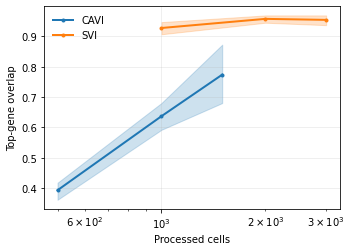

In [6]:
plot_history = pd.read_csv(RESULTS_DIR / "history.csv")
fig, ax = plt.subplots(figsize=(5.0, 3.6))

for method, method_df in plot_history.groupby("method"):
    curves = []
    for _, rep_df in method_df.groupby("rep"):
        rep_df = rep_df.sort_values("processed_cells").drop_duplicates("processed_cells", keep="last")
        rep_df = rep_df.dropna(subset=["processed_cells", "top_gene_overlap"])
        if not rep_df.empty:
            curves.append(rep_df.set_index("processed_cells")["top_gene_overlap"])

    common_cells = sorted(set.intersection(*[set(c.index) for c in curves])) if curves else []
    if not common_cells:
        continue
    grid = np.asarray(common_cells, dtype=float)
    values = np.vstack([[float(c.loc[v]) for v in common_cells] for c in curves])
    mean = np.nanmean(values, axis=0)
    lo, hi = np.nanquantile(values, [0.10, 0.90], axis=0)

    line, = ax.plot(grid, mean, marker="o", linewidth=2, markersize=3, label=method)
    if values.shape[0] > 1:
        ax.fill_between(grid, lo, hi, alpha=0.22, color=line.get_color())

ax.set_xlabel("Processed cells")
ax.set_ylabel("Top-gene overlap")
ax.set_xscale("log")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()


Compare topic recovery accuracy over wall-clock runtime using topic total variation distance.

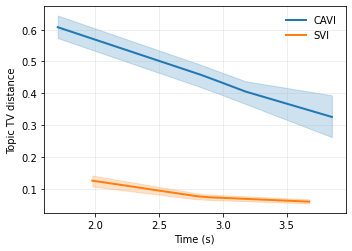

In [7]:
plot_history = pd.read_csv(RESULTS_DIR / "history.csv")
fig, ax = plt.subplots(figsize=(5.0, 3.6))

for method, method_df in plot_history.groupby("method"):
    rep_frames = []
    for _, rep_df in method_df.groupby("rep"):
        rep_df = rep_df.sort_values("runtime").drop_duplicates("runtime", keep="last")
        rep_df = rep_df.dropna(subset=["runtime", "topic_tv"])
        if not rep_df.empty:
            rep_frames.append(rep_df)

    if not rep_frames:
        continue
    start = max(float(rep_df["runtime"].min()) for rep_df in rep_frames)
    stop = min(float(rep_df["runtime"].max()) for rep_df in rep_frames)
    if stop <= start:
        continue
    grid = np.linspace(start, stop, 80)
    values = np.vstack([
        np.interp(grid, rep_df["runtime"].to_numpy(float), rep_df["topic_tv"].to_numpy(float))
        for rep_df in rep_frames
    ])
    mean = np.nanmean(values, axis=0)
    lo, hi = np.nanquantile(values, [0.10, 0.90], axis=0)

    line, = ax.plot(grid, mean, linewidth=2, label=method)
    if values.shape[0] > 1:
        ax.fill_between(grid, lo, hi, alpha=0.22, color=line.get_color())

ax.set_xlabel("Time (s)")
ax.set_ylabel("Topic TV distance")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()


Show the runtime cost of each method as a function of the number of processed cells.

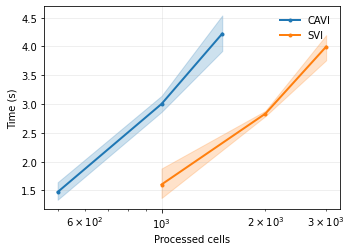

In [8]:
plot_history = pd.read_csv(RESULTS_DIR / "history.csv")
fig, ax = plt.subplots(figsize=(5.0, 3.6))

for method, method_df in plot_history.groupby("method"):
    curves = []
    for _, rep_df in method_df.groupby("rep"):
        rep_df = rep_df.sort_values("processed_cells").drop_duplicates("processed_cells", keep="last")
        rep_df = rep_df.dropna(subset=["processed_cells", "runtime"])
        if not rep_df.empty:
            curves.append(rep_df.set_index("processed_cells")["runtime"])

    common_cells = sorted(set.intersection(*[set(c.index) for c in curves])) if curves else []
    if not common_cells:
        continue
    grid = np.asarray(common_cells, dtype=float)
    values = np.vstack([[float(c.loc[v]) for v in common_cells] for c in curves])
    mean = np.nanmean(values, axis=0)
    lo, hi = np.nanquantile(values, [0.10, 0.90], axis=0)

    line, = ax.plot(grid, mean, marker="o", linewidth=2, markersize=3, label=method)
    if values.shape[0] > 1:
        ax.fill_between(grid, lo, hi, alpha=0.22, color=line.get_color())

ax.set_xlabel("Processed cells")
ax.set_ylabel("Time (s)")
ax.set_xscale("log")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()